# CCO11: Visium HD

In [1]:
import scanpy as sc
import squidpy as sq
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pysam
from Bio import SeqIO
from pathlib import Path
import anndata as ad
import seaborn as sns

In [2]:
WORK_DIR = "/home/herbert/PyProjects/cocultured_organ/workspace/CCO11"
DATA_DIR = "/home/herbert/PyProjects/cocultured_organ/data/260416"
os.system(f"mkdir -p {WORK_DIR}")

0

In [3]:
os.system(f"mkdir -p {WORK_DIR}/data/orig")

0

# -2. rerun SpaceRanger

In [4]:
os.system(f"mkdir -p {WORK_DIR}/spaceranger")

0

In [6]:
os.system(f"mkdir -p {WORK_DIR}/spaceranger/reference")

0

In [10]:
os.system(f"qsub {WORK_DIR}/spaceranger/run/run.sh")

requested Hard Resources
  memory (s_vmem): 4G = The job requires 4GB of memory per slot.
  slots (def_slot): 32 = The job requires 3200% of CPU.
  total memory: 128G = The job requires 128GB of memory.
Your job 121702474 ("run.sh") has been submitted


0

# -1. re-map

In [12]:
os.system(f"mkdir -p {WORK_DIR}/remap")
os.system(f"mkdir -p {WORK_DIR}/remap/ref")

0

In [42]:
os.system(f"qsub {WORK_DIR}/remap/ref/build_star_index.sh")

requested Hard Resources
  memory (s_vmem): 4G = The job requires 4GB of memory per slot.
  slots (def_slot): 32 = The job requires 3200% of CPU.
  total memory: 128G = The job requires 128GB of memory.
Your job 121721249 ("build_star_index.sh") has been submitted


0

In [43]:
os.system(f"qsub {WORK_DIR}/remap/map.sh")

requested Hard Resources
  memory (s_vmem): 4G = The job requires 4GB of memory per slot.
  slots (def_slot): 32 = The job requires 3200% of CPU.
  total memory: 128G = The job requires 128GB of memory.
Your job 121721857 ("map.sh") has been submitted


0

In [34]:
with open(f"{WORK_DIR}/remap/ref/Homo_sapiens.GRCh38.dna.temp.fa", "w") as f:
    for record in SeqIO.parse(f"{WORK_DIR}/remap/ref/Homo_sapiens.GRCh38.dna.toplevel.fa", "fasta"):
        header = None
        try:
            header = f"GRCh38_ch{int(record.id)}"
        except:
            if record.id in ("X", "Y", "MT"):
                header = f"GRCh38_ch{record.id}"
        if header is None:
            continue
        f.write(f">{header}\n")
        f.write(f"{str(record.seq)}\n")

with open(f"{WORK_DIR}/remap/ref/Rattus_norvegicus.mRatBN7.2.dna.temp.fa", "w") as f:
    for record in SeqIO.parse(f"{WORK_DIR}/remap/ref/Rattus_norvegicus.mRatBN7.2.dna.toplevel.fa", "fasta"):
        header = None
        try:
            header = f"mRatBN7_ch{int(record.id)}"
        except:
            if record.id in ("X", "Y", "MT"):
                header = f"mRatBN7_ch{record.id}"
        if header is None:
            continue
        f.write(f">{header}\n")
        f.write(f"{str(record.seq)}\n")

In [41]:
def rewrite_gtf_chroms(in_gtf, out_gtf, prefix):
    in_gtf = Path(in_gtf)
    out_gtf = Path(out_gtf)

    with in_gtf.open() as fin, out_gtf.open("w") as fout:
        for line in fin:
            if line.startswith("#"):
                fout.write(line)
                continue

            fields = line.rstrip("\n").split("\t")
            chrom = fields[0]

            fields[0] = f"{prefix}_ch{chrom}"

            fout.write("\t".join(fields) + "\n")


rewrite_gtf_chroms(
    f"{WORK_DIR}/remap/ref/Homo_sapiens.GRCh38.filtered.gtf",
    f"{WORK_DIR}/remap/ref/Homo_sapiens.GRCh38.renamed.gtf",
    "GRCh38"
)

rewrite_gtf_chroms(
    f"{WORK_DIR}/remap/ref/Rattus_norvegicus.mRatBN7.2.filtered.gtf",
    f"{WORK_DIR}/remap/ref/Rattus_norvegicus.mRatBN7.2.renamed.gtf",
    "mRatBN7"
)

In [44]:
samfile = pysam.AlignmentFile(f"{WORK_DIR}/remap/graftho_R2_Aligned.sortedByCoord.out.bam", "rb")
# samfile.check_index()

In [45]:
for i, s in enumerate(samfile):
    if i > 10:
        break
    print(s)

VH00387:807:AAHNWG2M5:1:1101:37962:32540	0	#0	17007	3	7S42M1S	*	0	0	AACATGGTCTCAGGCACCTGGCCCAGGTCTGGCACATAGAAGTAGTTCTA	array('B', [40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40])	[('NH', 2), ('HI', 1), ('AS', 41), ('nM', 0)]
VH00387:807:AAHNWG2M5:1:1210:67615:23567	0	#0	17007	3	7S42M1S	*	0	0	AACATGGTCTCAGGCACCTGGCCCAGGTCTGGCACATAGAAGTAGTTCTA	array('B', [40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 24, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40])	[('NH', 2), ('HI', 1), ('AS', 41), ('nM', 0)]
VH00387:807:AAHNWG2M5:1:1210:71175:26444	0	#0	17007	3	7S42M1S	*	0	0	AACATGGTCTCAGGCACCTGGCCCAGGTCTGGCACATAGAAGTAGTTCTA	array('B', [40, 40, 40, 40, 40, 40, 40, 40, 24, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 24, 40, 40, 40, 40, 2

In [46]:
for i, read in enumerate(samfile.fetch(until_eof=True)):
    if i == 20:
        break
    print(f"""
{read.query_name}
strand: {"-" if read.is_reverse else "+"}
chrom: {read.reference_name}
chrom_id: {read.reference_id}
start: {read.reference_start}
end: {read.reference_end}
cigar: {read.cigarstring}
splice: {read.cigartuples}
tags: {dict(read.tags)}
""")


VH00387:807:AAHNWG2M5:1:2311:44930:7172
strand: +
chrom: GRCh38_ch1
chrom_id: 0
start: 17006
end: 17048
cigar: 7S42M1S
splice: [(4, 7), (0, 42), (4, 1)]
tags: {'NH': 2, 'HI': 1, 'AS': 41, 'nM': 0}


VH00387:807:AAHNWG2M5:1:2311:45252:7304
strand: +
chrom: GRCh38_ch1
chrom_id: 0
start: 17006
end: 17048
cigar: 7S42M1S
splice: [(4, 7), (0, 42), (4, 1)]
tags: {'NH': 2, 'HI': 1, 'AS': 41, 'nM': 0}


VH00387:807:AAHNWG2M5:1:2407:57731:18190
strand: +
chrom: GRCh38_ch1
chrom_id: 0
start: 17006
end: 17048
cigar: 7S42M1S
splice: [(4, 7), (0, 42), (4, 1)]
tags: {'NH': 2, 'HI': 1, 'AS': 41, 'nM': 0}


VH00387:807:AAHNWG2M5:1:1101:37962:32540
strand: +
chrom: GRCh38_ch1
chrom_id: 0
start: 187528
end: 187570
cigar: 7S42M1S
splice: [(4, 7), (0, 42), (4, 1)]
tags: {'NH': 2, 'HI': 2, 'AS': 41, 'nM': 0}


VH00387:807:AAHNWG2M5:1:1210:67615:23567
strand: +
chrom: GRCh38_ch1
chrom_id: 0
start: 187528
end: 187570
cigar: 7S42M1S
splice: [(4, 7), (0, 42), (4, 1)]
tags: {'NH': 2, 'HI': 2, 'AS': 41, 'nM': 0}

# 0. convert to h5ad

In [20]:
for group in ("S11__graftho-JW-030626", "S11__graftvasho-JW-032626"):
    for bin_size in ("002um", "008um", "016um"):
        df = pd.read_parquet(f"{DATA_DIR}/{group}/outs/binned_outputs/square_{bin_size}/spatial/tissue_positions.parquet")
        df.to_csv(f"{DATA_DIR}/{group}/outs/binned_outputs/square_{bin_size}/spatial/tissue_positions_list.csv", index=False, header=False)
        os.system(f"ln -sfn {DATA_DIR}/{group}/outs/spatial/* {DATA_DIR}/{group}/outs/binned_outputs/square_{bin_size}/spatial")

In [22]:
# for group_path, group in zip(("S11__graftho-JW-030626", "S11__graftvasho-JW-032626"), ("HO", "VasHO")):
#     for res in ("002um", "008um", "016um"):
#         adata = sc.read_visium(
#             path=f"/home/herbert/PyProjects/cocultured_organ/data/260416/spaceranger/{group_path}/outs/binned_outputs/square_{res}", 
#             count_file="filtered_feature_bc_matrix.h5",
#         )
#         adata.var_names_make_unique()
#         adata.write(f"{WORK_DIR}/data/orig/{group}.{res}.h5ad")

# 1. process data

In [5]:
os.system(f"mkdir -p {WORK_DIR}/data/processed")
os.system(f"mkdir -p {WORK_DIR}/data/clustered")
os.system(f"mkdir -p {WORK_DIR}/data/labelled")

os.system(f"mkdir -p {WORK_DIR}/umap")
os.system(f"mkdir -p {WORK_DIR}/dotplot")
os.system(f"mkdir -p {WORK_DIR}/spatial")

0

In [69]:
res = "008um"
# for group, group_long, cluster_index in zip(("HO", ), ("S11__graftho-JW-030626", ), (6, )):
for group, group_long, cluster_index in zip(("HO", "VasHO"), ("S11__graftho-JW-030626", "S11__graftvasho-JW-032626"), (6, 5)):
    adata = sc.read_h5ad(f"{WORK_DIR}/data/orig/{group}.{res}.h5ad")
    df = pd.read_csv(f"{DATA_DIR}/spaceranger/{group_long}/outs/binned_outputs/square_{res}/analysis/clustering/gene_expression_graphclust/clusters.csv", index_col=0)
    
    df_sub = df[df["Cluster"] == cluster_index]
    adata_sub = adata[df_sub.index]

    sc.pp.normalize_total(adata_sub, target_sum=1e4)
    sc.pp.log1p(adata_sub)
    adata_sub.write(f"{WORK_DIR}/data/processed/{group}.{res}.h5ad")
    # sc.tl.pca(adata_sub, svd_solver="arpack")
    # sc.pp.neighbors(adata_sub, n_neighbors=15, n_pcs=30)
    # sc.tl.leiden(adata_sub, resolution=0.6)
    # sc.tl.umap(adata_sub)
    
    # # UMAP cluster
    # sc.pl.umap(adata_sub, color="leiden", title=group)
    # sc.pl.dotplot(adata_sub, marker_dict, groupby="leiden", title=group)

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/preprocessing/_normalization.py:169: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/preprocessing/_normalization.py:169: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [5]:
marker_dict = [
    "CDH5", "PECAM1", "CLDN5", "KDR", "NOS3", "VWF", "CD34", "ENG", "TEK", "PLVAP",
    "VEGFA", "PDPN", "MYH7", "ACTC1", "TNNT2", "TNNI1", "TNNI3", "MYL2", "MYL7",
    "ACTA2", "TAGLN", "MYH11", "CNN1", "NOTCH3", "PDGFRB", "RGS5", "CSPG4", "MGP", "ABCC9",
    "NR2F1", "CXCL12", "PDGFRA", "C7", "EDN1", "COL1A1", "COL1A2", "FN1", "ITGA11", "LGALS1",
    "FBLN2", "SERPINE2", "THY1", "KRT8", "CDH1", "EPCAM"
]

adata_ho = sc.read_h5ad(f"{WORK_DIR}/data/processed/HO.008um.h5ad")
adata_vho = sc.read_h5ad(f"{WORK_DIR}/data/processed/VasHO.008um.h5ad")

adata_all = ad.concat(
    [adata_ho, adata_vho], 
    axis=0, 
    join="inner", 
    label="batch",  
    keys=["HO", "VasHO"]
)

sc.tl.pca(adata_all, svd_solver="arpack")
sc.pp.neighbors(adata_all, n_neighbors=15, n_pcs=30)
sc.tl.leiden(adata_all, resolution=0.5)
sc.tl.umap(adata_all)

# UMAP cluster
ax = sc.pl.umap(adata_all, color="leiden", show=False)
plt.savefig(f"{WORK_DIR}/umap/all.png", bbox_inches="tight")
plt.savefig(f"{WORK_DIR}/umap/all.svg", bbox_inches="tight")
plt.close()

ax = sc.pl.dotplot(adata_all, marker_dict, groupby="leiden", standard_scale="var", dot_max=0.6, show=False)
plt.savefig(f"{WORK_DIR}/dotplot/all.png", bbox_inches="tight")
plt.savefig(f"{WORK_DIR}/dotplot/all.svg", bbox_inches="tight")
plt.close()

adata_all.write(f"{WORK_DIR}/data/clustered/all.h5ad")
for group in ("HO", "VasHO"):
    adata = adata_all[adata_all.obs["batch"] == group]
    adata.write(f"{WORK_DIR}/data/clustered/{group}.h5ad")

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


In [10]:
def plot_spatial(adata, adata_ori, figsize=(8,8), s=1, xlim=(-500, 0), ylim=(-500, 0), title="Spatial", s_legend=5, color_label=None, color_gene=None, color_gene_range=(0, 5), color_label_dict=None):
    common = adata.obs_names.intersection(adata_ori.obs_names)
    adata_sub = adata[common].copy()
    adata_ori_sub = adata_ori[common].copy()
    adata_sub.obsm["spatial"] = adata_ori_sub.obsm["spatial"].copy()
    adata_sub.uns["spatial"] = adata_ori.uns["spatial"].copy()
    
    fig, ax = plt.subplots(figsize=figsize)
    
    if color_label != None:
        # for l in adata_sub.obs[color_label].unique():
        all_labels = list(adata_sub.obs[color_label].unique())
        all_labels.sort()
        for l in all_labels:
            idx = adata_sub.obs[color_label] == l
            if color_label_dict is None:
                ax.scatter(
                    -adata_sub.obs.loc[idx, "array_col"],
                    -adata_sub.obs.loc[idx, "array_row"],
                    s=s,
                    label=l
                )
            else:
                ax.scatter(
                    -adata_sub.obs.loc[idx, "array_col"],
                    -adata_sub.obs.loc[idx, "array_row"],
                    s=s,
                    label=l, 
                    color=color_label_dict[l]
                )
        ax.legend(markerscale=s_legend, bbox_to_anchor=(1.05, 1), loc="upper left")
        
    if color_gene != None:
        scatter = ax.scatter(
            -adata_sub.obs.loc[:, "array_col"],
            -adata_sub.obs.loc[:, "array_row"],
            s=s,
            c=adata_sub[:,color_gene].X.toarray().ravel(),
            cmap='Reds', 
            vmin=color_gene_range[0], 
            vmax=color_gene_range[1],
        )
        cbar = plt.colorbar(scatter, ax=ax)
        
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_title(title)
    return fig, ax

In [78]:
celltype_marker_genes = {
    "EC": ['CDH5', 'PECAM1'], 
    "CM": ['TNNI1', 'ACTN2', 'MYH7', 'MYL2', 'TNNT2'], 
    "PVSC": ['PDGFRB', "RGS5", "COL1A1"]
}

colormap_cell_types = {
    "CM": (43/255, 119/255, 56/255),
    "EC": (231/255, 76/255, 60/255),
    "EP": (141/255, 160/255, 203/255),
    "PVSC": (218/255, 150/255, 18/255),
    "UN": (191/255, 200/255, 201/255),
}

In [79]:
# adata.X[:, adata.var_names == "THY1"]

In [84]:
for group in ("HO", "VasHO"):
    adata = sc.read_h5ad(f"{WORK_DIR}/data/clustered/{group}.h5ad")
    adata_ori = sc.read_h5ad(f"{WORK_DIR}/data/orig/{group}.008um.h5ad")
    
    adata.obs_names = adata.obs_names.str.replace(r"-1$", "", regex=True)
    adata_ori.obs_names = adata_ori.obs_names.str.replace(r"-1$", "", regex=True)
    
    common = adata.obs_names.intersection(adata_ori.obs_names)
    adata = adata[common].copy()
    adata_ori_sub = adata_ori[common].copy()
    adata.obsm["spatial"] = adata_ori_sub.obsm["spatial"].copy()
    adata.uns["spatial"] = adata_ori.uns["spatial"].copy()
    assert (adata.obs_names == adata_ori_sub.obs_names).all()
    
    if group == "VasHO":
        s = 4
        xlim = (-360, -220)
        # ylim = (-470, -330)
        # xlim = (-220, -360)
        ylim = (-330, -470)
    else:
        # s = 0.3
        s = 4
        xlim = (-340, -200)
        ylim = (-390, -250)
        
    fig, ax = plot_spatial(adata=adata, adata_ori=adata_ori, s=s, xlim=xlim, ylim=ylim, color_label="leiden", title=f"Spatial: {group}")
    plt.savefig(f"{WORK_DIR}/spatial/{group}.leiden.png", bbox_inches="tight")
    plt.savefig(f"{WORK_DIR}/spatial/{group}.leiden.svg", bbox_inches="tight")
    plt.close()

    marker_genes = ("PECAM1", "CDH5", "KDR")
    for marker_gene in marker_genes:
        fig, ax = plot_spatial(adata=adata, adata_ori=adata_ori, s=s, xlim=xlim, ylim=ylim, color_gene=marker_gene, title=f"Spatial: {marker_gene}")
        plt.savefig(f"{WORK_DIR}/spatial/{group}.{marker_gene}.png", bbox_inches="tight")
        plt.savefig(f"{WORK_DIR}/spatial/{group}.{marker_gene}.svg", bbox_inches="tight")
        plt.close()
        # plt.show()

    ax = sc.pl.umap(adata, color="leiden", title=f"UMAP: {group}", show=False)
    plt.savefig(f"{WORK_DIR}/umap/{group}.png", bbox_inches="tight")
    plt.savefig(f"{WORK_DIR}/umap/{group}.svg", bbox_inches="tight")
    plt.close()

    for ct in celltype_marker_genes:
        genes_present = [g for g in celltype_marker_genes[ct] if g in adata.var_names]
        X = adata[:, genes_present].X
        adata.obs[ct] = np.asarray((X > 0).sum(axis=1) > 0).ravel()
        adata.obs[ct] = np.asarray((X > 0).sum(axis=1) / len(celltype_marker_genes[ct])).ravel()

    cols = ["EC", "CM", "PVSC"]
    adata.obs["celltype"] = adata.obs[cols].idxmax(axis=1)
    adata.obs.loc[adata.obs[cols].eq(0).all(axis=1), "celltype"] = "UN"
        
    # adata.obs["celltype"] = np.select([
    #     adata.obs["EC"],
    #     adata.obs["PVSC"],
    #     adata.obs["CM"], ],["EC", "PVSC", "CM", ],
    #     default="UN"
    # )
    
    fig, ax = plot_spatial(
        adata=adata, 
        adata_ori=adata_ori, 
        s=s, 
        xlim=xlim, 
        ylim=ylim, 
        color_label="celltype", 
        title=f"Spatial: {group}", 
        color_label_dict=colormap_cell_types
    )
    plt.savefig(f"{WORK_DIR}/spatial/{group}.celltype.png", bbox_inches="tight")
    plt.savefig(f"{WORK_DIR}/spatial/{group}.celltype.svg", bbox_inches="tight")
    plt.close()

    if group == "HO":
        fig, ax = plot_spatial(
            adata=adata, 
            adata_ori=adata_ori, 
            s=0.4, 
            xlim=(-500, -150), 
            ylim=(-500, -150), 
            color_label="celltype", 
            title=f"Spatial: {group}", 
            color_label_dict=colormap_cell_types
        )
        plt.savefig(f"{WORK_DIR}/spatial/{group}.celltype.complete.png", bbox_inches="tight")
        plt.savefig(f"{WORK_DIR}/spatial/{group}.celltype.complete.svg", bbox_inches="tight")
        plt.close()

    adata.write(f"{WORK_DIR}/data/labelled/{group}.h5ad")

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


In [85]:
adata.obs["celltype"].value_counts()

celltype
CM      2139
UN       372
EC        80
PVSC      32
Name: count, dtype: int64

In [81]:
# for ct in celltype_marker_genes:
#     genes_present = [g for g in celltype_marker_genes[ct] if g in adata.var_names]
#     X = adata[:, genes_present].X
#     adata.obs[ct] = np.asarray((X > 0).sum(axis=1) > 0).ravel()

# adata.obs["celltype"] = np.select([
#     adata.obs["EC"],
#     adata.obs["PVSC"],
#     adata.obs["CM"],
# ],["EC", "PVSC", "CM", ],
#     default="UN"
# )

# fig, ax = plot_spatial(
#     adata=adata, 
#     adata_ori=adata_ori, 
#     s=s, 
#     xlim=xlim, 
#     ylim=ylim, 
#     color_label="celltype", 
#     title=f"Spatial: {group}", 
#     color_label_dict=colormap_cell_types
# )

# 2. DE

In [40]:
os.system(f"rm -r {WORK_DIR}/DE")
os.system(f"mkdir -p {WORK_DIR}/DE")

0

In [41]:
import scipy
def volcano_plot2(adata1, 
                  label1, 
                  label2, 
                  title, 
                  label_type='cell_type_subcluster', 
                  keygenes=None, 
                  save=None, 
                  save_tsv=None,
                  fc_thres=1, 
                  pvalue_thres=5):
    
    PSEUDOCOUNT=0.0001
    data1 = adata1.X[adata1.obs[label_type] == label1, :].todense().copy() + PSEUDOCOUNT
    data2 = adata1.X[adata1.obs[label_type] == label2, :].todense().copy() + PSEUDOCOUNT

    foldchanges = np.log2(
        np.divide(
            np.mean(data2,axis=0),
            np.mean(data1,axis=0)
        )
    )
    foldchanges = np.squeeze(np.asarray(foldchanges))

    means = np.mean(np.concatenate((data1, data2), axis=0), axis=0)
    s = np.squeeze(np.asarray(means)) ** 0.5
    s = s / s.mean() * 5

    ttest_results = scipy.stats.ttest_ind(
        data1,
        data2,
        axis=0,
        equal_var=False
    )
    pvalues = ttest_results[1]
    pvalues[pvalues == 0] = np.min(pvalues[pvalues > 0])
    transformed_pvalues = -1*np.log10(np.array(pvalues))

    idx_signi = [i for i in range(len(transformed_pvalues)) if transformed_pvalues[i] >= pvalue_thres]
    idx_inc = [i for i in idx_signi if foldchanges[i] > fc_thres]
    idx_dec = [i for i in idx_signi if foldchanges[i] < -1 * fc_thres]

    plt.scatter(foldchanges, 
                transformed_pvalues, 
                label='not significant',
                color='grey',
                alpha=0.5,
                s=s)
    plt.scatter(foldchanges[idx_inc], 
                transformed_pvalues[idx_inc], 
                label='up-regulated',
                color='red',
                alpha=0.5,
                s=s[idx_inc])
    plt.scatter(foldchanges[idx_dec], 
                transformed_pvalues[idx_dec], 
                label='down-regulated',
                color='blue',
                alpha=0.5,
                s=s[idx_dec])
    
    if keygenes is not None:
        for keygene in keygenes:
            gene_idx = adata1.var_names.tolist().index(keygene)
            plt.text(foldchanges[gene_idx], transformed_pvalues[gene_idx], keygene, ha='center', va='center')
            

    plt.xlabel('Log2FC')
    plt.ylabel('-log10 p-value')
    plt.title(title)
    plt.legend()
    if save is not None:
        plt.savefig(save)
        plt.close()
    else:
        plt.show()
    
    if save_tsv is not None:
        de_dict = {}
        de_dict['gene'] = adata1.var_names.to_list()
        de_dict['expression_1'] = np.squeeze(np.asarray(np.mean(data1, axis=0))) - PSEUDOCOUNT
        de_dict['expression_2'] = np.squeeze(np.asarray(np.mean(data2, axis=0))) - PSEUDOCOUNT
        de_dict['log2FC'] = foldchanges
        de_dict['-log10 p-val'] = transformed_pvalues
        de_dict['significant'] = [0 if (transformed_pvalues[i] < pvalue_thres or abs(foldchanges[i]) < fc_thres) else 1 for i in range(len(transformed_pvalues))]
        df = pd.DataFrame(de_dict)
        df.to_csv(save_tsv, sep='\t')
        df[df['significant'] == 1].to_csv(f"{(save_tsv).strip('.tsv')}.deg.tsv", sep='\t')

        if keygenes is not None and len(keygenes) > 0:
            df[df['gene'].isin(keygenes)].to_csv(f"{(save_tsv).strip('.tsv')}.marker.tsv", sep='\t')

## 2.1 CM

In [42]:
adata = sc.read_h5ad(f"{WORK_DIR}/data/labelled/HO.h5ad")
adata_ho = adata[adata.obs["celltype"] == "CM"]
adata = sc.read_h5ad(f"{WORK_DIR}/data/labelled/VasHO.h5ad")
adata_vasho = adata[adata.obs["celltype"] == "CM"]

adata_cm = ad.concat([adata_ho, adata_vasho])
# sc.pp.normalize_total(adata_cm, target_sum=1e4)

In [43]:
# "ADM, ALDOA, ANKRD37, BHLHE40, BHLHE41, BNIP3, DDIT3, DDIT4, EGLN3, ENO2, HILPDA, HK2, LDHA, NDRG1, NDUFA4L2, P4HA1, PDK1, PFKFB3, PFKFB4, PGK1, SLC2A1, SLC2A3, STC1, STC2, TRIB3, TXNIP, VEGFA".replace(" ", "").replace(",","','")

In [44]:
hypoxia_genes = ['NDRG1', 'STC1', 'STC2', 'BHLHE40', 'BHLHE41', 'DDIT3', 'DDIT4', 'EGLN3','SLC2A1','SLC2A3','HK2', 'ENO2', 'ANKRD37', 'TRIB3', 'VEGFA']

In [45]:
volcano_plot2(adata_cm, 
              label1 = "HO", 
              label2 = "VasHO", 
              title = "CM: HO vs VasHO", 
              label_type='batch', 
              keygenes=hypoxia_genes,
              save=f"{WORK_DIR}/DE/CM.HO.VasHO.png", 
              save_tsv=f"{WORK_DIR}/DE/CM.HO.VasHO.tsv",
              fc_thres=1, 
              pvalue_thres=5)

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


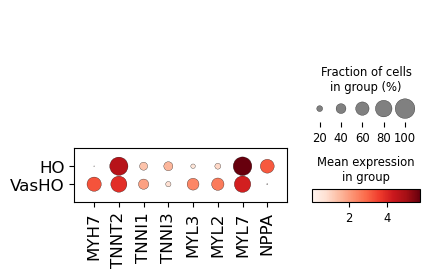

In [46]:
var_names = ['MYH7', 'TNNT2', 'TNNI1', 'TNNI3', 'MYL3', 'MYL2', 'MYL7', 'NPPA']
dp = sc.pl.dotplot(
    adata_cm, 
    groupby="batch", 
    var_names=var_names,
    return_fig=True,
    show=False
)

dp.make_figure()
ax = dp.ax_dict["mainplot_ax"]
ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=12)

plt.savefig(f'{WORK_DIR}/dotplot/CM.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/dotplot/CM.svg', bbox_inches="tight")
plt.show()

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


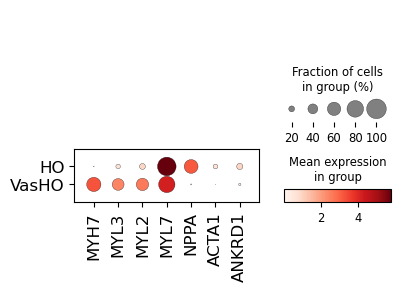

In [47]:
var_names = ['MYH7', 'MYL3', 'MYL2', 'MYL7', 'NPPA', 'ACTA1', 'ANKRD1']
dp = sc.pl.dotplot(
    adata_cm, 
    groupby="batch", 
    var_names=var_names,
    return_fig=True,
    show=False
)

dp.make_figure()
ax = dp.ax_dict["mainplot_ax"]
ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=12)

plt.savefig(f'{WORK_DIR}/dotplot/CM.2.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/dotplot/CM.2.svg', bbox_inches="tight")
plt.show()

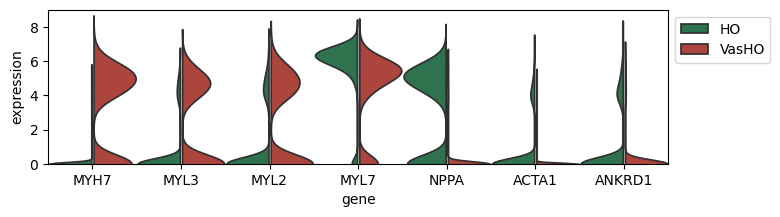

In [48]:
plot_df = {"batch": [], "gene": [], "expression": []}

for g in ['MYH7', 'MYL3', 'MYL2', 'MYL7', 'NPPA', 'ACTA1', 'ANKRD1']:
    plot_df["batch"] = plot_df["batch"] + adata_cm.obs["batch"].to_list()
    plot_df["gene"] = plot_df["gene"] + [g] * adata_cm.n_obs
    plot_df["expression"] = plot_df["expression"] + adata_cm.X[:, adata_cm.var_names == g].toarray().ravel().tolist()

plot_df = pd.DataFrame(plot_df)

fig, ax = plt.subplots(1, 1, figsize=(8, 2))

sns.violinplot(
    ax=ax,
    data=plot_df, 
    x="gene", 
    y="expression", 
    hue="batch", 
    split=True, 
    inner=None,
    density_norm='count',
    width=1,
    gap=.05,
    palette={"HO": "#227f4d", "VasHO": "#c0352c"}
    
)

ax.set_ylim(0, 9)
ax.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0))

plt.savefig(f'{WORK_DIR}/dotplot/CM.violin.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/dotplot/CM.violin.svg', bbox_inches="tight")

plt.show()

## 2.2 PVSC

In [49]:
adata = sc.read_h5ad(f"{WORK_DIR}/data/labelled/HO.h5ad")
adata_ho = adata[adata.obs["celltype"] == "PVSC"]
adata = sc.read_h5ad(f"{WORK_DIR}/data/labelled/VasHO.h5ad")
adata_vasho = adata[adata.obs["celltype"] == "PVSC"]

adata_pvsc = ad.concat([adata_ho, adata_vasho])

In [50]:
volcano_plot2(adata_pvsc, 
              label1 = "HO", 
              label2 = "VasHO", 
              title = "PVSC: HO vs VasHO", 
              label_type='batch', 
              save=f"{WORK_DIR}/DE/PVSC.HO.VasHO.png", 
              save_tsv=f"{WORK_DIR}/DE/PVSC.HO.VasHO.tsv",
              fc_thres=1, 
              pvalue_thres=5)

/tmp/ipykernel_2164539/780116578.py:29: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


## 2.3 UN

In [51]:
adata = sc.read_h5ad(f"{WORK_DIR}/data/labelled/HO.h5ad")
adata_ho = adata[adata.obs["celltype"] == "UN"]
adata = sc.read_h5ad(f"{WORK_DIR}/data/labelled/VasHO.h5ad")
adata_vasho = adata[adata.obs["celltype"] == "UN"]

adata_un = ad.concat([adata_ho, adata_vasho])

In [52]:
volcano_plot2(adata_un, 
              label1 = "HO", 
              label2 = "VasHO", 
              title = "UN: HO vs VasHO", 
              label_type='batch', 
              save=f"{WORK_DIR}/DE/UN.HO.VasHO.png", 
              save_tsv=f"{WORK_DIR}/DE/UN.HO.VasHO.tsv",
              fc_thres=1, 
              pvalue_thres=5)

/tmp/ipykernel_2164539/780116578.py:29: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


# 3. distribution

In [53]:
os.system(f"mkdir -p {WORK_DIR}/distribution")

0

In [82]:
adata_ho = sc.read_h5ad(f"{WORK_DIR}/data/labelled/HO.h5ad")
adata_vasho = sc.read_h5ad(f"{WORK_DIR}/data/labelled/VasHO.h5ad")

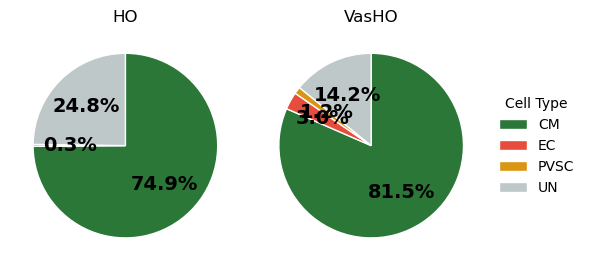

In [83]:
fig, axs = plt.subplots(1, 2, figsize=(6, 3))

for i, ct in enumerate(["HO", "VasHO"]):
    if ct == "HO":
        adata = adata_ho
    else:
        adata = adata_vasho
    counts = adata.obs["celltype"].value_counts().sort_index()
    colors = [colormap_cell_types.get(ct, "lightgray") for ct in counts.index]
    ax = axs[i]
    
    wedges, _, _ = ax.pie(
        counts.values,
        colors=colors,
        autopct="%1.1f%%",
        startangle=90,
        counterclock=False,
        wedgeprops={"edgecolor": "white", "linewidth": 1},
        textprops={
            "fontsize": 14,
            "fontweight": "bold",
            "color": "black",
        },
    )
    if i == 1:
        ax.legend(
            wedges,
            counts.index,
            title="Cell Type",
            loc="center left",
            bbox_to_anchor=(1, 0.5),
            frameon=False,
        )
    
    ax.set_title(ct)
    ax.set_aspect("equal")

plt.tight_layout()
plt.savefig(f"{WORK_DIR}/distribution/piechart.png", bbox_inches="tight")
plt.savefig(f"{WORK_DIR}/distribution/piechart.svg", bbox_inches="tight")
plt.show()

# 4. Co-localization

In [5]:
adata_vasho = sc.read_h5ad(f"{WORK_DIR}/data/labelled/VasHO.h5ad")

In [6]:
adata_vasho

AnnData object with n_obs × n_vars = 2623 × 18085
    obs: 'in_tissue', 'array_row', 'array_col', 'batch', 'leiden', 'EC', 'CM', 'PVSC', 'celltype'
    uns: 'leiden', 'leiden_colors', 'neighbors', 'pca', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [9]:
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree


def build_neighbor_graph(obs, radius=2):
    coords = obs[["array_row", "array_col"]].values
    tree = cKDTree(coords)
    neighbors = tree.query_ball_point(coords, r=radius)
    neighbors = [[j for j in x if j != i] for i, x in enumerate(neighbors)]
    return neighbors


def count_edges(labels, neighbors, source="EC", target="PVSC"):
    total = 0
    for i, nbrs in enumerate(neighbors):
        if labels[i] != source:
            continue
        total += np.sum(labels[nbrs] == target)
    return total


def permutation_test_ec_pvsc(obs, n_perm=2000, random_state=42):

    neighbors = build_neighbor_graph(obs)

    labels = obs["celltype"].values

    observed = count_edges(labels, neighbors)

    rng = np.random.default_rng(random_state)

    perm = np.zeros(n_perm)

    for i in range(n_perm):
        shuffled = rng.permutation(labels)
        perm[i] = count_edges(shuffled, neighbors)

    z = (observed - perm.mean()) / perm.std()

    p = (np.sum(perm >= observed) + 1) / (n_perm + 1)

    return observed, perm, z, p

In [10]:
obs = adata_vasho.obs

obs_score, perm_scores, z, p = permutation_test_ec_pvsc(obs)

print(obs_score)
print(z)
print(p)

280
3.6856176303463752
0.0004997501249375312


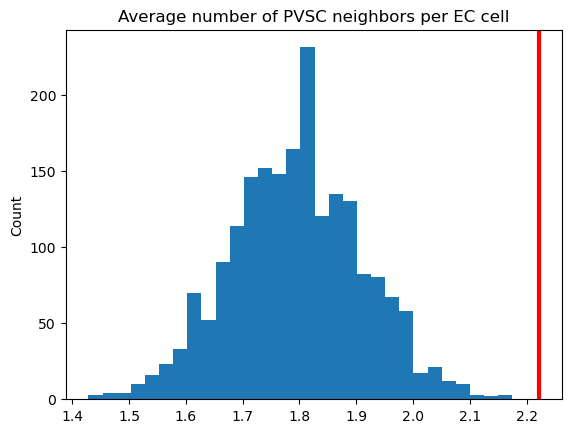

In [15]:
import matplotlib.pyplot as plt

n_ec = (adata_vasho.obs["celltype"] == "EC").sum()

plt.hist(perm_scores/n_ec, bins=30)
plt.axvline(obs_score/n_ec, color="red", lw=3)
# plt.xlabel("EC-PVSC neighbor edges")
plt.ylabel("Count")
plt.title("Average number of PVSC neighbors per EC cell")
plt.show()

In [17]:
def empty_neighbor_fraction(obs):

    coords = obs[["array_row","array_col"]].values

    coord_set = set(map(tuple, coords))

    offsets = [
        (-1,-1),(-1,0),(-1,1),
        (0,-1),        (0,1),
        (1,-1),(1,0),(1,1)
    ]

    frac = np.zeros(len(obs))

    for i,(r,c) in enumerate(coords):

        empty = 0

        for dr,dc in offsets:

            if (r+dr,c+dc) not in coord_set:
                empty += 1

        frac[i] = empty/8

    return frac

<Axes: xlabel='celltype', ylabel='boundary_fraction'>

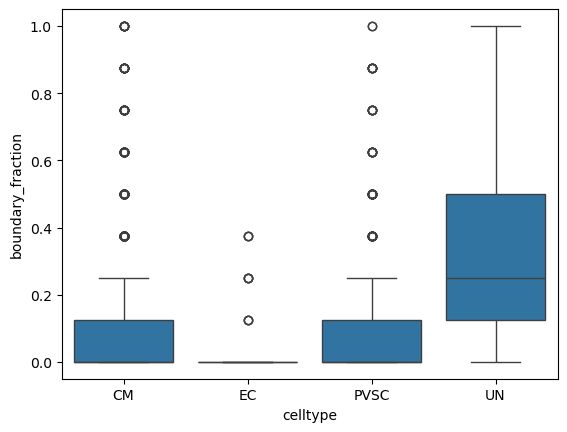

In [19]:
obs["boundary_fraction"] = empty_neighbor_fraction(obs)

sns.boxplot(
    data=obs,
    x="celltype",
    y="boundary_fraction",
)

In [41]:
def permutation_test_boundary(obs,
                              target="UN",
                              n_perm=1000,
                              random_state=0):

    frac = empty_neighbor_fraction(obs)

    labels = obs["celltype"].values

    observed = frac[labels==target].mean()

    rng = np.random.default_rng(random_state)

    perm = np.zeros(n_perm)

    for i in range(n_perm):

        shuffled = rng.permutation(labels)

        perm[i] = frac[shuffled==target].mean()

    z = (observed-perm.mean())/perm.std()

    p = (np.sum(perm>=observed)+1)/(n_perm+1)

    return observed, perm, z, p

In [42]:
obs_mean, perm_mean, z, p = permutation_test_boundary(obs)

print(obs_mean)
print(z)
print(p)

0.33887987012987014
18.008479956569662
0.000999000999000999


In [ ]:
sns.boxplot(
    data=obs,
    x="celltype",
    y="boundary_fraction"
)